# 0. Imports

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
     ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
     ---------------------------------------- 6.2/6.2 MB 76.0 MB/s eta 0:00:00
     ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
     ---------------------------------------- 536.2/536.2 kB ? eta 0:00:00
   ---------------------------------------- 0.0/2.7 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 GB 99.4 MB/s eta 0:00:28
    --------------------------------------- 0.0/2.7 GB 99.4 MB/s eta 0:00:28
    --------------------------------------- 0.1/2.7 GB 95.6 MB/s eta 0:00:28
   - -------------------------------------- 0.1/2.7 GB 95.6 MB/s eta 0:00:28
   - -------------------------------------- 0.1/2.7 GB 92.3 MB/s eta 0:00:29
   - -------------------------------------- 0.1/2.7 GB 93.3 MB/s eta 0:00:29
   -- ------------------------------------- 0.1/2.7 GB 93.8 MB/s eta 0:00:28
   -- -----------------------------


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from itertools import combinations
from collections import Counter
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [5]:
import os
data_path = os.path.join(os.getcwd(), 'data')

# 1. Helper Functions

## 1.2 Find the most frequent combinations of categories in a df column

In [6]:
def get_top_k_p_combinations(df, comb_p, topk, output_freq=False):
    '''
    params:
        df: input dataframe
        comb_p: number of elements in each combination (e.g., there are two elements in the combination {fried chicken, chicken and waffle}, and three elements in the combination {fried chicken, chicken and waffle, chicken fried rice})
        topk: number of most frequent combinations to retrieve
        output_freq: whether to return the frequencies of retrieved combinations

    return:
        1. output_freq = True: a list X where each element is a tuple containing a combination tuple and corresponding frequency, and the elements are stored in the descending order of their frequencies
        2. output_freq = False: a list X where each element is a tuple containing a combination tuple, and the elements are stored in the descending order of their frequencies
    '''
    def get_category_combinations(categories, comb_p=2):
        return list(combinations(categories, comb_p))
    all_categories_p_combos = df["category"].apply(lambda x: get_category_combinations(x, comb_p)).values.tolist()
    all_categories_p_combos = [tuple(t) for item in all_categories_p_combos for t in item]
    tmp = dict(Counter(all_categories_p_combos))
    sorted_categories_combinations = list(sorted(tmp.items(), key=lambda x: x[1], reverse=True))
    if output_freq:
        return sorted_categories_combinations[:topk]
    else:
        return [t[0] for t in sorted_categories_combinations[:topk]]

## 1.3 Create a OHE (or "wide feature representation") of each row in the column of a df

In [22]:
def get_wide_features(df, selected_categories_to_idx, top_combinations):
    '''
    params:
        df: input dataframe
        selected_categories_to_idx: a dictionary mapping item categories to corrresponding integral indices
        top_combinations: a list containing retrieved mostly frequent combinantions of item categories

    return:
        a numpy array where each row contains the categorical features' binary encodings and cross product transformations for the corresponding row of the input dataframe
    '''
    def categories_to_binary_output(categories):
        binary_output = [0 for _ in range(len(selected_categories_to_idx))]
        for category in selected_categories_to_idx:
            if category in selected_categories_to_idx:
                binary_output[selected_categories_to_idx[category]] = 1
            else:
                binary_output[0] = 1
        return binary_output
    
    def categories_cross_transformation(categories):
        current_category_set = set(categories)
        corss_transform_output = [0 for _ in range(len(top_combinations))]

        # Iterate through each combination and its index
        for k, comb_k in enumerate(top_combinations):
            # If the current category set is a subset of the combination, set the output to 1
            if len(current_category_set & comb_k) == len(comb_k):
                corss_transform_output[k] = 1
            # Otherwise, set the output to 0
            else:
                corss_transform_output[k] = 0
        return corss_transform_output

    # Apply the two functions to the category column
    category_binary_features = np.array(df.category.apply(lambda x: categories_to_binary_output(x)).values.tolist())
    # Apply the second function to the category column
    category_cross_transform_features = np.array(df.category.apply(lambda x: categories_cross_transformation(x)).values.tolist())
    # Concatenate the two arrays
    return np.concatenate((category_binary_features, category_cross_transform_features), axis=1)

# 2. Data Handling

## 2.1 Data Exploration

In [8]:
prediction_data = pd.read_csv(os.path.join(data_path, 'prediction.csv'))
product_data = pd.read_json(os.path.join(data_path, 'product.json'))
review_data = pd.read_csv(os.path.join(data_path, 'review.csv'))
validation_data = pd.read_csv(os.path.join(data_path, 'validation.csv'))

print(f"Prediction data shape: {prediction_data.shape}")
print(f"Product data shape: {product_data.shape}")
print(f"Review data shape: {review_data.shape}")
print(f"Validation data shape: {validation_data.shape}")

Prediction data shape: (6633, 3)
Product data shape: (6309, 17)
Review data shape: (52512, 5)
Validation data shape: (6596, 3)


In [9]:
review_data

,ReviewerID,ProductID,Text,Summary,Star
0,A1XJXYKOWCH9XT,B000FBFMHU,Liked the movie. Loved the book. It really giv...,Liked the movie. Loved the book!,5.0
1,A1K4S4MWXI9E9M,B000FC27TA,Purchased more out of curiosity than any real ...,"Not my favorite, but...",3.0
2,A3LF914GG87TWP,B000FC27TA,"I actually received this text as an ebook, sin...",An interesting read,4.0
3,A1CNQTCRQ35IMM,B000FCKPG2,REVIEWER'S OPINION:\r\nThis was labeled as rom...,This was labeled romance but there was less ro...,2.0
4,AU510CVD9XDG,B000GCFWXW,I have been saving the Argeneau novels for awh...,Science Fiction not Paranormal Romance,2.0
...,...,...,...,...,...
52507,A3JVZY05VLMYEM,B01FLJUZ0E,She can't do anything right according to her f...,What Can She Do,5.0
52508,A2U06P692IZOSF,B01FLJUZ0E,Better late than never!!\r\nKitty Konstantine ...,BART & KITTY CAT MAKE SPARKS FLY!!,5.0
52509,A3RPL8JIS2XMJ3,B01FLJUZ0E,This book was great. Bartholomew finally gets ...,LOVE THE SAINTS,5.0
52510,A1XMFCMIANCQRW,B01FPYJS1M,I read for a honest review for the author.\r\n...,"Loved Lee and Raina together, Ricky is evil an...",4.0


In [7]:
prediction_data

,ReviewerID,ProductID,Star
0,A2MK1L1Y74WTWH,B01GT5XDFS,0
1,A19I68RW4PBT29,B00OME9OQQ,0
2,A1UPHTDW5GM12T,B01GSRNLOK,0
3,A1LFIFPYMOJ8RV,B01CUJYMR0,0
4,A10Y597K071WTQ,B004SI455Q,0
...,...,...,...
6628,A23Y4UGTFDMZOP,B00J5327X6,0
6629,A2PFNDDKHOOMZU,B01G0GIXJ2,0
6630,A1K4S4MWXI9E9M,B01FKDKB96,0
6631,AOLHNMI8G8R6K,B00NUDPR66,0


In [10]:
validation_data

,ReviewerID,ProductID,Star
0,A25X28UZCW2J6G,B00K9V6B94,4.0
1,A1FUH1O6FCTUYG,B00GZANS6M,5.0
2,AAUVEEG5YLZAX,B01864DDVO,5.0
3,A3VQLGTYTL5196,B001BXNQ2O,5.0
4,A10JAUCIGVRW9F,B0116MZUS2,5.0
...,...,...,...
6591,A3TC60MGLW1I76,B00EHSUFD8,4.0
6592,AGE0YGLF7L2ZL,B014LQ18CW,4.0
6593,AT2ZB20OCU7X2,B00ZRDPPU0,4.0
6594,A1ACUN6A2LYVMW,B01EKIELGG,1.0


In [ ]:
product_data_df_train = pd.DataFrame(train_df)

In [11]:
product_data.iloc[0].category

['Kindle Store', 'Kindle eBooks', 'Biographies & Memoirs']

## 2.2 Preprocessing

### 2.2.1 Merging the train_df and val_df

In [ ]:
import json
with open('data/product.json', 'r') as f:
    product_data_json = json.load(f)

product_data_json[100]

Create a dictionary version of product data with key=product_id for clarity

In [81]:
product_data_json_structured = {product_data_json[i]['ProductID']: product_data_json[i] for i in range(len(product_data_json))}

In [85]:
product_data_json_structured

{'B000FBFMHU': {'category': ['Kindle Store',
   'Kindle eBooks',
   'Biographies & Memoirs'],
  'tech1': '',
  'description': [],
  'fit': '',
  'title': '',
  'tech2': '',
  'brand': "Visit Amazon's Frank W. Abagnale Page",
  'feature': [],
  'rank': '59,404 Paid in Kindle Store (',
  'details': {'File Size:': '1466 KB',
   'Print Length:': '304 pages',
   'Page Numbers Source ISBN:': '076791435X',
   'Publisher:': 'Broadway Books (November 19, 2002)',
   'Publication Date:': 'November 19, 2002',
   'Language:': 'English',
   'ASIN:': 'B000FBFMHU',
   'Word Wise:': 'Enabled',
   'Lending:': 'Enabled'},
  'main_cat': 'Buy a Kindle',
  'similar_item': '',
  'date': '',
  'price': '',
  'imageURL': [],
  'imageURLHighRes': [],
  'ProductID': 'B000FBFMHU'},
 'B000FC27TA': {'category': ['Kindle Store',
   'Kindle eBooks',
   'Politics & Social Sciences',
   '</span>'],
  'tech1': '',
  'description': [],
  'fit': '',
  'title': '',
  'tech2': '',
  'brand': "Visit Amazon's Karl Marx Page",

## Extracting Relevant Information from Product Data

#### Find Product IDs intersection with review and validation data

In [114]:
with open('data/product.json', 'r') as f:
    product_data_json = json.load(f)

product_data_ids = set([product_data_json[i]['ProductID'] for i in range(len(product_data_json))])
review_data_ids = set(review_data['ProductID'].unique())
validation_data_ids = set(validation_data['ProductID'].unique())
prediction_data_ids = set(prediction_data['ProductID'].unique())

review_and_product = review_data_ids.intersection(product_data_ids)
validation_and_product = validation_data_ids.intersection(product_data_ids)

prediction_and_product = set(prediction_data['ProductID'].unique())
prediction_and_product = prediction_data_ids.intersection(product_data_ids)


### Organize the dataframes for the intersected data

##### For Review data

In [112]:
columns_of_interest = ["category", "brand", "rank"]
product_review_df = pd.DataFrame({
    "ProductID": list(review_and_product),
    "category": [product_data_json_structured[key]['category'][2] if len(product_data_json_structured[key]['category']) > 2 else "unknown" for key in review_and_product],
    "author": [product_data_json_structured[key]['brand'] for key in review_and_product],
    "rank": [product_data_json_structured[key]['rank'] for key in review_and_product]
})

product_review_df['author'] = product_review_df['author'].str.replace('Visit Amazon\'s ', '').str.replace(' Page', '').str.strip()
product_review_df['rank'] = product_review_df['rank'].str.replace(r'[^\d]', '', regex=True).fillna(0).astype(int)
product_review_df

,ProductID,category,author,rank
0,B00GFZMO5S,Literature & Fiction,Tamika Newhouse,876390
1,B0193VFINK,Literature & Fiction,Beverly Jenkins,443218
2,B003YFIVUY,Literature & Fiction,Anita Shreve,36155
3,B015OBIIVC,Romance,Cari Quinn,158754
4,B00Q5IJ55C,Literature & Fiction,Lynda Chance,147523
...,...,...,...,...
6304,B0058KRVIG,Literature & Fiction,Vincent Hobbes,25687
6305,B00YP3ZAS0,"Comics, Manga & Graphic Novels",Nick Abadzis,5462
6306,B00QNYKI7C,"Mystery, Thriller & Suspense",Tim McGregor,3089
6307,B00KIAMGDQ,Literature & Fiction,Jack Silkstone,670420


##### For validation data

In [113]:
product_validation_df = pd.DataFrame({
    "ProductID": list(validation_and_product),
    "category": [product_data_json_structured[key]['category'][2] if len(product_data_json_structured[key]['category']) > 2 else "unknown" for key in validation_and_product],
    "author": [product_data_json_structured[key]['brand'] for key in validation_and_product],
    "rank": [product_data_json_structured[key]['rank'] for key in validation_and_product]
})

product_validation_df['author'] = product_validation_df['author'].str.replace('Visit Amazon\'s ', '').str.replace(' Page', '').str.strip()
product_validation_df['rank'] = product_validation_df['rank'].str.replace(r'[^\d]', '', regex=True).fillna(0).astype(int)
product_validation_df

,ProductID,category,author,rank
0,B01B0QXBA8,Literature & Fiction,Tabatha Kiss,211100
1,B01EKPNQKG,Literature & Fiction,Aiden Bates,465786
2,B004W9BX7Y,Literature & Fiction,Nina Pierce,1788497
3,B01F07IBWG,Romance,Serena Rose,232381
4,B011T78JT6,Romance,Sable Sylvan,60810
...,...,...,...,...
2486,B016WNZI78,Literature & Fiction,Ella Summers,36935
2487,B017R65QS0,Literature & Fiction,Frances Hodgson Burnett,1079214
2488,B00ET7Q4OG,Religion & Spirituality,Vannetta Chapman,7036
2489,B00LDQOZWO,Literature & Fiction,Renita Pizzitola,280622


##### For Prediction Data

In [115]:
product_prediction_df = pd.DataFrame({
    "ProductID": list(prediction_and_product),
    "category": [product_data_json_structured[key]['category'][2] if len(product_data_json_structured[key]['category']) > 2 else "unknown" for key in prediction_and_product],
    "author": [product_data_json_structured[key]['brand'] for key in prediction_and_product],
    "rank": [product_data_json_structured[key]['rank'] for key in prediction_and_product]
})

product_prediction_df['author'] = product_prediction_df['author'].str.replace('Visit Amazon\'s ', '').str.replace(' Page', '').str.strip()
product_prediction_df['rank'] = product_prediction_df['rank'].str.replace(r'[^\d]', '', regex=True).fillna(0).astype(int)
product_prediction_df

,ProductID,category,author,rank
0,B01B0QXBA8,Literature & Fiction,Tabatha Kiss,211100
1,B011T78JT6,Romance,Sable Sylvan,60810
2,B00NZLNUXA,Romance,Sylvia Frost,12288
3,B00V8RF05Y,Romance,K Webster,165865
4,B00CF4U874,Literature & Fiction,Kitty Thomas,352709
...,...,...,...,...
2466,B017R65QS0,Literature & Fiction,Frances Hodgson Burnett,1079214
2467,B00ET7Q4OG,Religion & Spirituality,Vannetta Chapman,7036
2468,B00LDQOZWO,Literature & Fiction,Renita Pizzitola,280622
2469,B016XN3HMK,Religion & Spirituality,Andrea Twombly,176793


#### Merge and Create the Train, validation and Test DF

In [118]:
train_df = pd.merge(review_data[['ReviewerID', 'ProductID', 'Star']], product_review_df, on='ProductID').reset_index(drop=True)
val_df = pd.merge(validation_data, product_validation_df, on='ProductID').reset_index(drop=True)
pred_df = pd.merge(prediction_data, product_prediction_df, on='ProductID').reset_index(drop=True)

In [120]:
train_df.head()

,ReviewerID,ProductID,Star,category,author,rank
0,A1XJXYKOWCH9XT,B000FBFMHU,5.0,Biographies & Memoirs,Frank W. Abagnale,59404
1,A1K4S4MWXI9E9M,B000FC27TA,3.0,Politics & Social Sciences,Karl Marx,1358073
2,A3LF914GG87TWP,B000FC27TA,4.0,Politics & Social Sciences,Karl Marx,1358073
3,A1CNQTCRQ35IMM,B000FCKPG2,2.0,Romance,Allison Brennan,94006
4,AU510CVD9XDG,B000GCFWXW,2.0,"Mystery, Thriller &amp; Suspense",Lynsay Sands,31652


In [121]:
val_df.head()


,ReviewerID,ProductID,Star,category,author,rank
0,A25X28UZCW2J6G,B00K9V6B94,4.0,Science Fiction & Fantasy,Erin Kellison,607901
1,A1FUH1O6FCTUYG,B00GZANS6M,5.0,Literature & Fiction,Evangeline Anderson,74267
2,AAUVEEG5YLZAX,B01864DDVO,5.0,Literature & Fiction,Lucia Jordan,13716
3,A3VQLGTYTL5196,B001BXNQ2O,5.0,Literature & Fiction,Eve Vaughn,730348
4,A30WJKGX1XG19Q,B00I4KRGPA,2.0,Literature & Fiction,Violet Duke,11765


In [122]:
pred_df.head()

,ReviewerID,ProductID,Star,category,author,rank
0,A2MK1L1Y74WTWH,B01GT5XDFS,0,Literature & Fiction,Raleigh Blake,8693
1,A19I68RW4PBT29,B00OME9OQQ,0,Literature & Fiction,Jodi Watters,126504
2,A1UPHTDW5GM12T,B01GSRNLOK,0,Romance,Scarlett Grove,295526
3,A1LFIFPYMOJ8RV,B01CUJYMR0,0,Romance,Bijou Hunter,5661
4,A10Y597K071WTQ,B004SI455Q,0,Science Fiction & Fantasy,Nicole Williams,10819


In [14]:
val_df

,ReviewerID,ProductID,Star,category,brand
0,A25X28UZCW2J6G,B00K9V6B94,4.0,"[Kindle Store, Kindle eBooks, Science Fiction ...",Erin Kellison
1,A1FUH1O6FCTUYG,B00GZANS6M,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Evangeline Anderson
2,AAUVEEG5YLZAX,B01864DDVO,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Lucia Jordan
3,A3VQLGTYTL5196,B001BXNQ2O,5.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Eve Vaughn
4,A30WJKGX1XG19Q,B00I4KRGPA,2.0,"[Kindle Store, Kindle eBooks, Literature & Fic...",Violet Duke
...,...,...,...,...,...
5437,A3TC60MGLW1I76,B00EHSUFD8,4.0,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Jaden Skye
5438,AGE0YGLF7L2ZL,B014LQ18CW,4.0,"[Kindle Store, Kindle eBooks, Romance]",Susan Hatler
5439,AT2ZB20OCU7X2,B00ZRDPPU0,4.0,"[Kindle Store, Kindle eBooks, Mystery, Thrille...",Lee Child
5440,A1ACUN6A2LYVMW,B01EKIELGG,1.0,"[Kindle Store, Kindle eBooks, Romance]",Lee Savino


In [123]:
print(train_df.info(), '\n')
print(val_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52328 entries, 0 to 52327
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ReviewerID  52328 non-null  object 
 1   ProductID   52328 non-null  object 
 2   Star        52328 non-null  float64
 3   category    52328 non-null  object 
 4   author      52328 non-null  object 
 5   rank        52328 non-null  int32  
dtypes: float64(1), int32(1), object(4)
memory usage: 2.2+ MB
None 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5442 entries, 0 to 5441
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ReviewerID  5442 non-null   object 
 1   ProductID   5442 non-null   object 
 2   Star        5442 non-null   float64
 3   category    5442 non-null   object 
 4   author      5442 non-null   object 
 5   rank        5442 non-null   int32  
dtypes: float64(1), int32(1), object(4)
memory usage: 234.0+ 

### 2.2.2 Preparing deep categorical features

In [16]:
deep_columns = ['brand']

deep_vocab_lens = []
for col_name in deep_columns:
    # Get unique values of this col
    unique_values = train_df[col_name].unique()

    # Put each unique value into a dict: (value, num), start num range from 1 onwards
    vocab = dict(zip(unique_values, range(1, len(unique_values) + 1)))

    # Add the number of items in the dict (+1 for unknown)
    deep_vocab_lens.append(len(vocab) + 1)

    # Add columns to the train_df to display the idx number of the OHE
    train_df[col_name + '_idx'] = train_df[col_name].apply(lambda x: vocab[x])

# Map ProductID to the _idx columns in train_df
deep_idx_columns = [t + "_idx" for t in deep_columns]
deep_categorical_features = dict(zip(train_df['ProductID'].values, train_df[deep_idx_columns].values.tolist()))

# Convert the _idx columns into np arrays for the model
train_deep_categorical_features = np.array(train_df['ProductID'].apply(lambda x: deep_categorical_features[x]).values.tolist())
val_deep_categorical_features = np.array(val_df['ProductID'].apply(lambda x: deep_categorical_features[x]).values.tolist())

In [17]:
len(train_deep_categorical_features), train_deep_categorical_features

(52328,
 array([[   1],
        [   2],
        [   2],
        ...,
        [3530],
        [3555],
        [3530]]))

In [18]:
len(val_deep_categorical_features), val_deep_categorical_features

(5442,
 array([[2133],
        [  49],
        [ 806],
        ...,
        [ 266],
        [3524],
        [3264]]))

### 2.2.3 Preparing wide features

Preparing binary encoding for each selected category

In [19]:
# Collect all categories from the category column
all_categories = []
for category_list in train_df.category.values:
    # Since category is already a list, we don't need to split it
    for category in category_list:
        all_categories.append(category)

# Sort all unique values of the categories by their frequencies in descending order
from collections import Counter
category_sorted = sorted(Counter(all_categories).items(), key=lambda x: x[1], reverse=True)

# Select top 500 most frequent categories
selected_categories = [t[0] for t in category_sorted[:500]]

# Create a dictionary mapping each selected category to a unique integral index
selected_categories_to_idx = dict(zip(selected_categories, range(1, len(selected_categories) + 1)))

# Map all categories unseen in the df to index 0
selected_categories_to_idx['unk'] = 0

# Create a dictionary mapping each integral index to corresponding category
idx_to_selected_categories = {val: key for key, val in selected_categories_to_idx.items()}

In [20]:
idx_to_selected_categories

{1: 'Kindle Store',
 2: 'Kindle eBooks',
 3: 'Literature & Fiction',
 4: 'Romance',
 5: 'Mystery, Thriller & Suspense',
 6: 'Science Fiction & Fantasy',
 7: 'Religion & Spirituality',
 8: 'Teen & Young Adult',
 9: "Children's eBooks",
 10: 'Health, Fitness & Dieting',
 11: 'Business & Money',
 12: 'Humor & Entertainment',
 13: 'Cookbooks, Food & Wine',
 14: '</span>',
 15: 'Biographies & Memoirs',
 16: 'Kindle Keyboard',
 17: 'Kindle DX',
 18: 'Kindle (2nd Generation)',
 19: 'Kindle (5th Generation)',
 20: 'Activities, Puzzles & Games',
 21: 'Politics & Social Sciences',
 22: 'Arts & Photography',
 23: 'Literature &amp; Fiction',
 24: 'Reference',
 25: 'Kindle Paperwhite',
 26: 'Kindle Paperwhite (5th Generation)',
 27: 'Kindle Touch',
 28: 'Crafts, Hobbies & Home',
 29: 'History',
 30: 'Computers & Technology',
 31: 'Science & Math',
 32: 'Self-Help',
 33: 'Education & Teaching',
 34: 'Word Games',
 35: 'Parenting & Relationships',
 36: 'Comics, Manga & Graphic Novels',
 37: 'Travel',

Preparing cross product transformation for categories

In [21]:
# Get most frequent categories combinantions using the utility function defined previously and store them in the folloing list
top_combinations = []

# Get top 50 most frequent two-categories combinantions in the train set
top_combinations += get_top_k_p_combinations(train_df, 3, 50, output_freq=False)

# Get top 30 most frequent three-categories combinantions in the train set
top_combinations += get_top_k_p_combinations(train_df, 3, 30, output_freq=False)

# Get top 20 most frequent four-categories combinantions in the train set
top_combinations += get_top_k_p_combinations(train_df, 4, 20, output_freq=False)

# Convert each combinantion in the list to a set data structure
top_combinations = [set(t) for t in top_combinations]

In [22]:
top_combinations

[{'Kindle Store', 'Kindle eBooks', 'Literature & Fiction'},
 {'Kindle Store', 'Kindle eBooks', 'Romance'},
 {'Kindle Store', 'Kindle eBooks', 'Mystery, Thriller & Suspense'},
 {'Kindle Store', 'Kindle eBooks', 'Science Fiction & Fantasy'},
 {'Kindle Store', 'Kindle eBooks', 'Religion & Spirituality'},
 {'Kindle Store', 'Kindle eBooks', 'Teen & Young Adult'},
 {"Children's eBooks", 'Kindle Store', 'Kindle eBooks'},
 {'Health, Fitness & Dieting', 'Kindle Store', 'Kindle eBooks'},
 {'Business & Money', 'Kindle Store', 'Kindle eBooks'},
 {'Humor & Entertainment', 'Kindle Store', 'Kindle eBooks'},
 {'Cookbooks, Food & Wine', 'Kindle Store', 'Kindle eBooks'},
 {'</span>', 'Kindle Store', 'Kindle eBooks'},
 {'Biographies & Memoirs', 'Kindle Store', 'Kindle eBooks'},
 {'</span>', 'Kindle Store', 'Literature & Fiction'},
 {'</span>', 'Kindle eBooks', 'Literature & Fiction'},
 {'Kindle Keyboard', 'Kindle Store', 'Kindle eBooks'},
 {'Kindle DX', 'Kindle Store', 'Kindle eBooks'},
 {'Kindle (2nd Ge

In [23]:
train_wide_features = get_wide_features(train_df, selected_categories_to_idx, top_combinations)
val_wide_features = get_wide_features(val_df, selected_categories_to_idx, top_combinations)

In [24]:
train_wide_features

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]])

In [25]:
val_wide_features

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]])

### 2.2.4 Concatenating deep categorical features and wide features as an input list

In [26]:
train_features = []
train_features += [train_deep_categorical_features[:, i] for i in range(train_deep_categorical_features.shape[1])]
train_features.append(train_wide_features)

val_features = []
val_features += [val_deep_categorical_features[:, i] for i in range(val_deep_categorical_features.shape[1])]
val_features.append(val_wide_features)

In [27]:
train_features

[array([   1,    2,    2, ..., 3530, 3555, 3530]),
 array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]])]

In [28]:
val_features

[array([2133,   49,  806, ...,  266, 3524, 3264]),
 array([[1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        ...,
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0],
        [1, 1, 1, ..., 0, 0, 0]])]

# 3. Model Implementation

## 3.1 Set up Dataset and Model

In [29]:
class RatingDataset(Dataset):
    def __init__(self, features, ratings):
        self.deep_categorical = [torch.LongTensor(f) for f in features[:-1]]
        self.wide = torch.FloatTensor(features[-1])
        self.ratings = torch.FloatTensor(ratings)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (
            *[dc[idx] for dc in self.deep_categorical],
            self.wide[idx],
            self.ratings[idx]
        )

In [30]:
class WideDeepModel(nn.Module):
    def __init__(self, deep_vocab_lens, len_wide, embed_size, hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size, embed_size) for vocab_size in deep_vocab_lens
        ])

        # DNN for the deep part
        layers = []
        input_dim = len(deep_vocab_lens) * embed_size
        for hd in hidden_dims:
            layers.append(nn.Linear(input_dim, hd))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = hd

        self.dnn = nn.Sequential(*layers)

        # Final FC combining deep + wide
        self.fc = nn.Linear(hidden_dims[-1] + len_wide, 1)

    def forward(self, *args):
        deep_categorical = args[:len(self.embeddings)]
        wide = args[-1]

        embeds = []
        for i, emb_layer in enumerate(self.embeddings):
            embeds.append(emb_layer(deep_categorical[i]))
        embeds = torch.cat(embeds, dim=1)

        dnn_output = self.dnn(embeds)

        combined = torch.cat([dnn_output, wide], dim=1)

        return self.fc(combined).squeeze()

In [31]:
train_ratings = train_df['Star'].values
val_ratings = val_df['Star'].values

## 3.2 Training the model

In [32]:
train_dataset = RatingDataset(train_features, train_ratings)
val_dataset = RatingDataset(val_features, val_ratings)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device", device)

model = WideDeepModel(
    deep_vocab_lens=deep_vocab_lens,
    len_wide=train_wide_features.shape[1],
    embed_size=100
)
model = model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epochs = 3
train_losses = []
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for brand, wide, ratings in train_loader:
        optimizer.zero_grad()
        outputs = model(
            brand.to(device),
            wide.to(device)
        )
        loss = criterion(outputs, ratings.to(device))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))
    print(f"Epoch {epoch+1} loss: {train_losses[-1]:.4f}")

using device cuda
Epoch 1 loss: 0.9868
Epoch 2 loss: 0.8524
Epoch 3 loss: 0.8592


## 3.3 Evaluation on validation data

In [33]:
def compute_rmse(model, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for brand, wide, ratings in loader:
            outputs = model(
                brand.to(device),
                wide.to(device)
            )
            total_loss += nn.MSELoss(reduction='sum')(outputs, ratings.to(device)).item()
    mse = total_loss / len(loader.dataset)
    return torch.sqrt(torch.tensor(mse)).item()

train_rmse = compute_rmse(model, train_loader)
val_rmse = compute_rmse(model, val_loader)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Train RMSE: 0.9217
Validation RMSE: 1.0526


## NN CF

In [48]:
%pip install ray[tune]

   ---------------------------------------- 0.0/25.7 MB ? eta -:--:--
   ------------------------------- -------- 20.2/25.7 MB 106.0 MB/s eta 0:00:01
   ---------------------------------------- 25.7/25.7 MB 90.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
review_data_selected = review_data[['ReviewerID', 'ProductID', 'Star']]
review_data_selected.head()


,ReviewerID,ProductID,Star
0,A1XJXYKOWCH9XT,B000FBFMHU,5.0
1,A1K4S4MWXI9E9M,B000FC27TA,3.0
2,A3LF914GG87TWP,B000FC27TA,4.0
3,A1CNQTCRQ35IMM,B000FCKPG2,2.0
4,AU510CVD9XDG,B000GCFWXW,2.0


In [23]:
df_train = review_data_selected.copy()
df_test = prediction_data.copy()
df_val = validation_data.copy()


In [31]:
def create_mapping(df):
    """
    Create a mapping from the unique values of the columns to integers, leaving 0 for missing values.
    """
    reviewer_ids = df['ReviewerID'].unique()
    product_ids = df['ProductID'].unique()

    reviewer_id_map = {reviewer_id: i + 1 for i, reviewer_id in enumerate(reviewer_ids)}
    product_id_map = {product_id: i + 1 for i, product_id in enumerate(product_ids)}
    return reviewer_id_map, product_id_map

In [24]:
df_train.columns

Index(['ReviewerID', 'ProductID', 'Star'], dtype='object')

In [25]:
df_val.columns


Index(['ReviewerID', 'ProductID', 'Star'], dtype='object')

In [26]:
df_test.columns

Index(['ReviewerID', 'ProductID', 'Star'], dtype='object')

### Create mappings between the reviewer ID and the product ID

In [32]:
user_map, item_map = create_mapping(df_train)
df_train['ReviewerID'] = df_train['ReviewerID'].map(user_map).fillna(0).astype(int)
df_train['ProductID'] = df_train['ProductID'].map(item_map).fillna(0).astype(int)

df_val['ReviewerID'] = df_val['ReviewerID'].map(user_map).fillna(0).astype(int)
df_val['ProductID'] = df_val['ProductID'].map(item_map).fillna(0).astype(int)

df_test['ReviewerID'] = df_test['ReviewerID'].map(user_map).fillna(0).astype(int)
df_test['ProductID'] = df_test['ProductID'].map(item_map).fillna(0).astype(int)

## Neural CF

### Define Dataset

In [37]:
class RatingDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['ReviewerID'].values, dtype=torch.long)
        self.items = torch.tensor(df['ProductID'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['Star'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

### Define Model

In [38]:
class NeuralCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=50, hidden_dim=64):
        super().__init__()
        self.user_embed = nn.Embedding(num_users+1, embedding_dim, padding_idx=0)
        self.item_embed = nn.Embedding(num_items+1, embedding_dim, padding_idx=0)
        self.fc_layers = nn.Sequential(
            nn.Linear(2*embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, 1)
        )
        
    def forward(self, user, item):
        user_vec = self.user_embed(user)
        item_vec = self.item_embed(item)
        concat = torch.cat([user_vec, item_vec], dim=-1)
        return self.fc_layers(concat).squeeze()

## Training Loop

In [39]:
# implement early stopping

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        elif val_loss < self.best_loss:
            self.best_loss = val_loss
        else:
            self.counter += 1
        
        if self.counter >= self.patience:
            return True
        return False


In [45]:
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeuralCF(num_users=len(user_map), num_items=len(item_map)).to(device)
model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

num_epochs = 50

train_dataset = RatingDataset(df_train)
val_dataset = RatingDataset(df_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False,
                        pin_memory=True)

early_stopping = EarlyStopping(patience=20, min_delta=0.001)

lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                     mode='min', patience=5, factor=0.5)

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for users, items, ratings in train_loader:
        user, item, rating = users.to(device), items.to(device), ratings.to(device)
        optimizer.zero_grad()
        pred = model(user, item)
        loss = criterion(pred, rating)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    print(f"Epoch {epoch+1} train loss: {train_losses[-1]:.4f}")

    avg_train_loss = sum(train_losses) / len(train_losses)
    print(f"Average train loss: {avg_train_loss:.4f}")

    model.eval()
    val_epoch_loss = 0
    with torch.no_grad():
        for users, items, ratings in val_loader:
            user, item, rating = users.to(device), items.to(device), ratings.to(device)
            pred = model(user, item)
            loss = criterion(pred, rating)
            val_epoch_loss += loss.item()
    avg_val_loss = val_epoch_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"Average validation loss: {avg_val_loss:.4f}")

    if early_stopping(avg_val_loss):
        print("Early stopping triggered")
        break

Epoch 1 train loss: 1.5277
Average train loss: 1.5277
Average validation loss: 1.2236
Epoch 2 train loss: 0.7022
Average train loss: 1.1150
Average validation loss: 1.1289
Epoch 3 train loss: 0.5825
Average train loss: 0.9375
Average validation loss: 1.1024
Epoch 4 train loss: 0.5190
Average train loss: 0.8329
Average validation loss: 1.1028
Epoch 5 train loss: 0.4755
Average train loss: 0.7614
Average validation loss: 1.1328
Epoch 6 train loss: 0.4400
Average train loss: 0.7078
Average validation loss: 1.1786
Epoch 7 train loss: 0.4070
Average train loss: 0.6648
Average validation loss: 1.2036
Epoch 8 train loss: 0.3730
Average train loss: 0.6283
Average validation loss: 1.2676
Epoch 9 train loss: 0.3400
Average train loss: 0.5963
Average validation loss: 1.3362
Epoch 10 train loss: 0.3101
Average train loss: 0.5677
Average validation loss: 1.4242
Epoch 11 train loss: 0.2782
Average train loss: 0.5414
Average validation loss: 1.5322
Epoch 12 train loss: 0.2507
Average train loss: 0.51

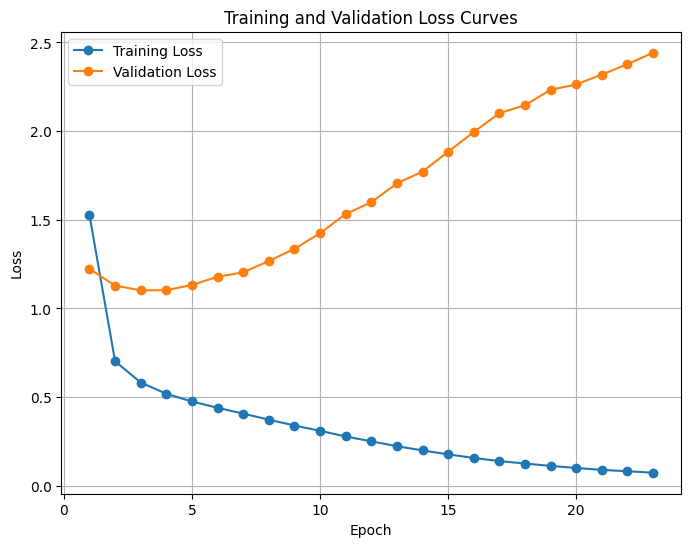

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label="Training Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label="Validation Loss") 
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()



In [44]:
def compute_rmse(model, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for brand, wide, ratings in loader:
            outputs = model(
                brand.to(device),
                wide.to(device)
            )
            total_loss += nn.MSELoss(reduction='sum')(outputs, ratings.to(device)).item()
    mse = total_loss / len(loader.dataset)
    return torch.sqrt(torch.tensor(mse)).item()

train_rmse = compute_rmse(model, train_loader)
val_rmse = compute_rmse(model, val_loader)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")




Train RMSE: 0.4127
Validation RMSE: 1.2996


In [46]:

train_rmse = compute_rmse(model, train_loader)
val_rmse = compute_rmse(model, val_loader)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Train RMSE: 0.2439
Validation RMSE: 1.5640


In [47]:
test_loader = DataLoader(RatingDataset(df_test), batch_size=64, shuffle=False, pin_memory=True)
test_rmse = compute_rmse(model, test_loader)
print(f"Test RMSE: {test_rmse:.4f}")

Test RMSE: 4.0297


## TODO: Hyper param tuning

In [ ]:
from ray import tune
from ray.tune.search import BayesOptSearch
from ray.tune import CLIReporter
from ray.tune import Checkpoint
